Original Class Distribution:
Result
Fail    16
Pass     2
Name: count, dtype: int64


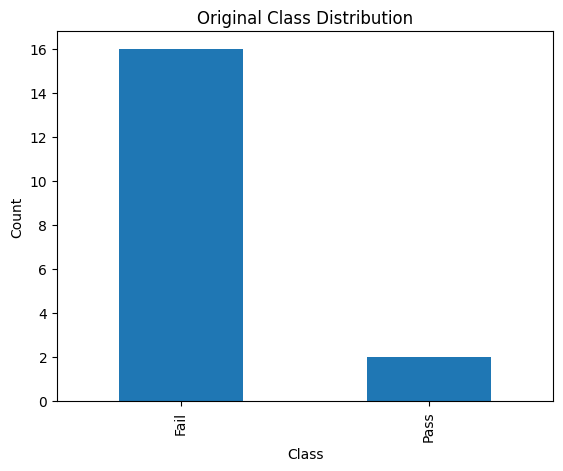


After Oversampling:
Result
Fail    16
Pass    16
Name: count, dtype: int64


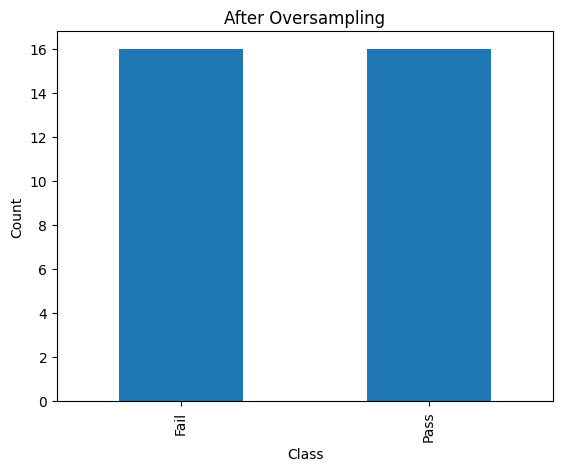


After Undersampling:
Result
Fail    2
Pass    2
Name: count, dtype: int64


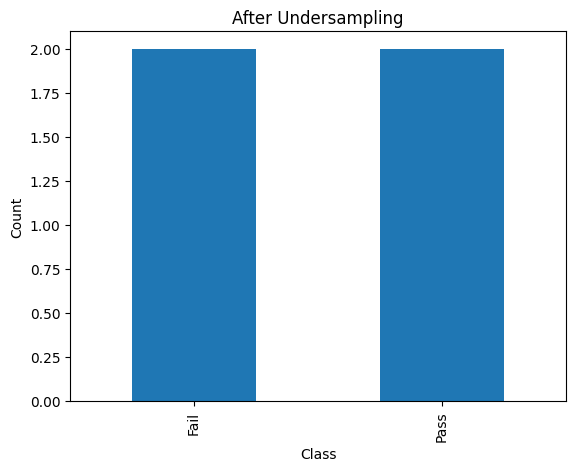


Balanced Dataset:
Result
Pass    16
Fail    16
Name: count, dtype: int64


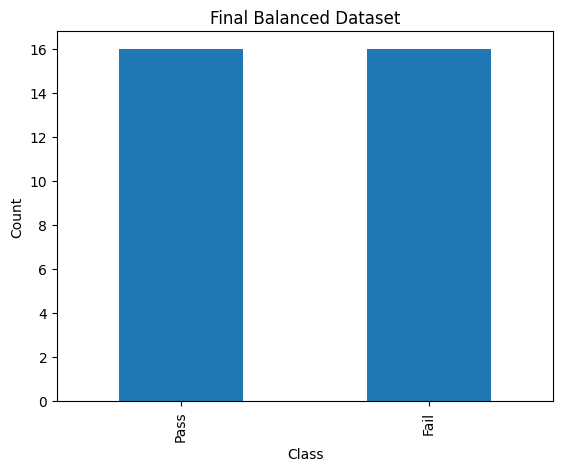

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
# Load dataset
df = pd.read_csv("data9.csv")

# ORIGINAL DISTRIBUTION
print("Original Class Distribution:")
print(df["Result"].value_counts())

df["Result"].value_counts().plot(kind='bar')
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# SEPARATE CLASSES
majority = df[df["Result"] == "Fail"]
minority = df[df["Result"] == "Pass"]

# OVERSAMPLING
minority_upsampled = resample(minority,
                             replace=True,
                             n_samples=len(majority),
                             random_state=42)

df_oversampled = pd.concat([majority, minority_upsampled])

print("\nAfter Oversampling:")
print(df_oversampled["Result"].value_counts())

df_oversampled["Result"].value_counts().plot(kind='bar')
plt.title("After Oversampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# UNDERSAMPLING
majority_downsampled = resample(majority,
                               replace=False,
                               n_samples=len(minority),
                               random_state=42)

df_undersampled = pd.concat([majority_downsampled, minority])

print("\nAfter Undersampling:")
print(df_undersampled["Result"].value_counts())

df_undersampled["Result"].value_counts().plot(kind='bar')
plt.title("After Undersampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# FINAL BALANCED DATA
df_balanced = df_oversampled.sample(frac=1)

print("\nBalanced Dataset:")
print(df_balanced["Result"].value_counts())

df_balanced["Result"].value_counts().plot(kind='bar')
plt.title("Final Balanced Dataset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()